**Proyecto II de Programación para Estadística ll**

**Tema:** La evolución del gasto corriente en salud (% del PIB), la pobreza y la incidencia de las enfermedades transmisibles y su variación entre países con diferentes desarrollos económicos durante la última década

**Profesor:** Michael Sanchez Soto

**Estudiantes:** Cyra Coto, Gustavo Jiménez y Abigail Murillo

**Pregunta**

¿Cómo ha evolucionado el gasto corriente en salud (% del PIB), la pobreza y la incidencia de las enfermedades transmisibles durante la última década y de qué manera varía esta relación entre países con diferentes niveles de desarrollo económico?

# 1. CARGA DE LAS BASES DE DATOS

In [2]:
#Importación de las librerías y carga de los datas frames crudos
import pandas as pd
import numpy as np
import json
from google.colab import files

# -----------------------
# 1. CARGA DE ARCHIVOS RAW
# -----------------------

print("SUBE ARCHIVO DENGUE 1")
uploaded_dengue = files.upload()
df_dengue = pd.read_excel(list(uploaded_dengue.keys())[0])

print("SUBE ARCHIVO HIV")
uploaded_hiv = files.upload()
df_HIV = pd.read_excel(
    list(uploaded_hiv.keys())[0],
    sheet_name="HIV-Test-&-Treat_ByYear",
    engine="openpyxl",
    skiprows=6
)

print("SUBE ARCHIVO INDICE DE POBREZA")
uploaded_pobreza = files.upload()
df_indice_pobreza = pd.read_csv(list(uploaded_pobreza.keys())[0])

print("SUBE ARCHIVO TUBERCULOSIS")
uploaded_tb = files.upload()
df_tuberculosis = pd.read_csv(list(uploaded_tb.keys())[0])

# -----------------------
# 2. CARGA DEL JSON
# -----------------------

print("SUBE ARCHIVO JSON DE GASTO EN SALUD")
uploaded_json = files.upload()
json_filename = list(uploaded_json.keys())[0]
print("JSON cargado:", json_filename)

# Leer JSON correctamente
with open(json_filename, "r", encoding="utf-8") as f:
    data_json = json.load(f)

# Normalizar JSON en DataFrame
df_gasto_salud = pd.json_normalize(data_json)

# -----------------------
# 3. SEGUNDO DATA FRAME DEL DENGUE
# -----------------------

print("SUBE ARCHIVO DENGUE 2")
uploaded_dengue2 = files.upload()
df_dengue2 = pd.read_csv(list(uploaded_dengue2.keys())[0])


SUBE ARCHIVO DENGUE 1


Saving dengue-global-data-2025-11-12.xlsx to dengue-global-data-2025-11-12 (1).xlsx
SUBE ARCHIVO HIV


Saving HIV_estimates_from_1990-to-present.xlsx to HIV_estimates_from_1990-to-present (1).xlsx
SUBE ARCHIVO INDICE DE POBREZA


Saving indice de pobreza global.csv to indice de pobreza global (1).csv
SUBE ARCHIVO TUBERCULOSIS


Saving number-of-tuberculosis-cases.csv to number-of-tuberculosis-cases (1).csv
SUBE ARCHIVO JSON DE GASTO EN SALUD


Saving Gasto_corriente_en_salud_PIB(1).json to Gasto_corriente_en_salud_PIB(1) (1).json
JSON cargado: Gasto_corriente_en_salud_PIB(1) (1).json
SUBE ARCHIVO DENGUE 2


Saving National_extract_V1_3.csv to National_extract_V1_3 (1).csv


# 2. PREPARACIÓN DE LA BASE DEL DENGUE

In [3]:
df_dengue.columns #exploracion de las columnas del data frame del dengue

Index(['date', 'date_lab', 'who_region', 'who_region_long', 'country', 'iso3',
       'cases', 'confirmed_cases', 'severe_cases', 'deaths', 'cfr', 'prop_sev',
       'cfr_ci_lower', 'cfr_ci_upper', 'prop_sev_ci_lower',
       'prop_sev_ci_upper'],
      dtype='object')

In [92]:
display(df_dengue) #exploracion del df crudo

,country,year,dengue_cases,tb_cases,hiv_cases
0,Afghanistan,2021,734.0,0.0,0.0
1,Afghanistan,2022,1341.0,0.0,0.0
2,Afghanistan,2023,1481.0,0.0,0.0
3,Afghanistan,2024,4850.0,0.0,0.0
4,Afghanistan,2025,115.0,0.0,0.0
...,...,...,...,...,...
10263,Zimbabwe,2020,0.0,29000.0,1174899.0
10264,Zimbabwe,2021,0.0,31000.0,1188450.0
10265,Zimbabwe,2022,0.0,34000.0,1233619.0
10266,Zimbabwe,2023,0.0,35000.0,1233934.0


In [5]:
df_dengue.isna().sum() #La base tiene varios varios NA's

,0
date,0
date_lab,0
who_region,0
who_region_long,0
country,0
iso3,0
cases,1328
confirmed_cases,3900
severe_cases,4299
deaths,2222


In [6]:
df_dengue.dtypes #Vemos que que las variables están en el formato correcto, además todos los valores faltantes son númericos, por lo que tenemos la posibilidad de sustituirlos con el valor de la mediana


,0
date,datetime64[ns]
date_lab,object
who_region,object
who_region_long,object
country,object
iso3,object
cases,float64
confirmed_cases,float64
severe_cases,float64
deaths,float64


In [7]:
df_dengue["cases"] = df_dengue["cases"].fillna("No indica")
df_dengue["confirmed_cases"] = df_dengue["confirmed_cases"].fillna("No indica") #LLenamos los valores faltantes con 0 ya que no hay registros
df_dengue["severe_cases"] = df_dengue["severe_cases"].fillna("No indica")
df_dengue["deaths"] = df_dengue["deaths"].fillna("No indica")
df_dengue["cfr"] = df_dengue["cfr"].fillna("Desconocido")
df_dengue["cfr_ci_upper"] = df_dengue["cfr_ci_upper"].fillna("Desconocido") #No sabemos hasta que número podría llegar
df_dengue["cfr_ci_lower"] = df_dengue["cfr_ci_lower"].fillna("Desconocido")
df_dengue["prop_sev"] = df_dengue["prop_sev"].fillna("Desconocido")
df_dengue["prop_sev_ci_lower"] = df_dengue["prop_sev_ci_lower"].fillna("Desconocido")
df_dengue["prop_sev_ci_upper"] = df_dengue["prop_sev_ci_upper"].fillna("Desconocido") #No sabemos hasta que número podría llegar
df_dengue["prop_sev_ci_lower"] = df_dengue["prop_sev_ci_lower"].fillna("Desconocido")



In [8]:
df_dengue.isna().sum() # Hemos limpiado los NA's

,0
date,0
date_lab,0
who_region,0
who_region_long,0
country,0
iso3,0
cases,0
confirmed_cases,0
severe_cases,0
deaths,0


In [9]:
df_dengue.duplicated().sum() #No posee duplicados

np.int64(0)

In [10]:

#Asegúrate de que 'date' sea datetime
df_dengue['date'] = pd.to_datetime(df_dengue['date'])

# Crear columna 'year'
df_dengue['year'] = df_dengue['date'].dt.year


# Convertir 'cases' a numérico, forzando errores a NaN
df_dengue['cases'] = pd.to_numeric(df_dengue['cases'], errors='coerce')

# Agrupar por país y año
df_dengue_final = df_dengue.groupby(['country', 'year'], as_index=False)['cases'].sum()

df_dengue_final.to_excel("dengue.xlsx", index=False)


## 2.2 SEGUNDA BASE DEL DENGUE

In [11]:
# --- PASO 1: quedarte solo con columnas importantes ---
df_dengue2x = df_dengue2[["adm_0_name", "ISO_A0", "Year", "dengue_total"]]

# --- PASO 2: convertir 'dengue_total' a numérico por si viene como string ---
df_dengue2["dengue_total"] = pd.to_numeric(df_dengue2["dengue_total"], errors="coerce")

# --- PASO 3: agrupar por país y año ---
df_dengue2_final = (
    df_dengue2.groupby(["adm_0_name", "ISO_A0", "Year"], as_index=False)
      .agg(total_cases=("dengue_total", "sum"))
)


df_dengue2_final.rename(columns={
    'adm_0_name': 'country',
    'ISO_A0': 'code',
    'Year': 'year',
    'total_cases': 'dengue_cases'
}, inplace=True)

# Verificar
print(df_dengue2_final.head())



# Resultado final
df_dengue2_final


       country code  year  dengue_cases
0  AFGHANISTAN  AFG  2021         734.0
1  AFGHANISTAN  AFG  2022        1341.0
2  AFGHANISTAN  AFG  2023        1481.0
3  AFGHANISTAN  AFG  2024        4850.0
4  AFGHANISTAN  AFG  2025         115.0


,country,code,year,dengue_cases
0,AFGHANISTAN,AFG,2021,734.0
1,AFGHANISTAN,AFG,2022,1341.0
2,AFGHANISTAN,AFG,2023,1481.0
3,AFGHANISTAN,AFG,2024,4850.0
4,AFGHANISTAN,AFG,2025,115.0
...,...,...,...,...
4328,YEMEN,YEM,2020,62028.0
4329,YEMEN,YEM,2021,7324.0
4330,YEMEN,YEM,2022,24545.0
4331,YEMEN,YEM,2023,21302.0


# 3. PREPARACION DE LA BASE DE LA TUBERCULOSIS

In [12]:
display(df_tuberculosis)

,Entity,Code,Year,Estimated number of new cases of all forms of tuberculosis
0,Afghanistan,AFG,2000,38000
1,Afghanistan,AFG,2001,38000
2,Afghanistan,AFG,2002,40000
3,Afghanistan,AFG,2003,43000
4,Afghanistan,AFG,2004,44000
...,...,...,...,...
5376,Zimbabwe,ZWE,2019,30000
5377,Zimbabwe,ZWE,2020,29000
5378,Zimbabwe,ZWE,2021,31000
5379,Zimbabwe,ZWE,2022,34000


In [13]:
df_tuberculosis.isna().sum() #La base posee varios NA's

,0
Entity,0
Code,240
Year,0
Estimated number of new cases of all forms of tuberculosis,0


In [14]:
df_tuberculosis.dtypes # Todas las variables son del tipo correcto de datos

,0
Entity,object
Code,object
Year,int64
Estimated number of new cases of all forms of tuberculosis,int64


In [15]:
df_tuberculosis["Code"] = df_tuberculosis["Code"].fillna("No especifica")

# 4. PREPARACION DE LA BASE GASTOS EN SALUD json

In [16]:
#Esta base es la de tipo json. requiere un tratamiento especial
#Quitar las primeras filas que no aportan informacion
df_temp = df_gasto_salud.copy()
df_temp = df_temp.iloc[2:].reset_index(drop=True)

#Usar la primera fila como encabezado real
#La nueva fila 0 ahora tiene los nombres reales de columnas (Country Name, Country Code, Indicator Name, 2000, 2001, ...)
new_header = df_temp.iloc[0]
df_temp = df_temp.iloc[1:].reset_index(drop=True)
df_temp.columns = new_header

#Eliminar columnas 'Unnamed' y vacías que hay varias
df_temp = df_temp.loc[:, ~df_temp.columns.astype(str).str.contains(r'^Unnamed', na=False)]
df_temp = df_temp[[c for c in df_temp.columns if str(c).strip() != '' and c is not None]]

#Pasar a formato largo (tidy) year–value o hacer la transposición
#nombres de columnas
rename_map = {
    'Country Name': 'country_name',
    'Country Code': 'country_code',
    'Indicator Name': 'indicator_name',
    'Indicator Code': 'indicator_code'  # por si existiera
}
df_temp = df_temp.rename(columns={k: v for k, v in rename_map.items() if k in df_temp.columns})

#Detectar columnas de año: están como '2000.0', '2001.0',...
def es_col_anio(col):
    s = str(col).strip()
    s = s[:-2] if s.endswith('.0') else s
    return s.isdigit() and len(s) == 4

year_cols = [c for c in df_temp.columns if es_col_anio(c)]
if not year_cols:
    raise ValueError("No se detectaron columnas de año. Revisa los nombres (p.ej. '2000.0').")

#Construir id_vars presentes
id_vars = [c for c in ['country_name', 'country_code', 'indicator_name', 'indicator_code'] if c in df_temp.columns]

df_largo = df_temp.melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name='year_raw',
    value_name='value'
)

#Convertir 'year_raw' a 'year' numérico limpio
def limpiar_year(y):
    s = str(y).strip()
    s = s[:-2] if s.endswith('.0') else s
    return pd.to_numeric(s, errors='coerce')

df_largo['year'] = df_largo['year_raw'].apply(limpiar_year)
df_largo.drop(columns=['year_raw'], inplace=True)

#Tipos y limpieza básica
df_largo['value'] = pd.to_numeric(df_largo['value'], errors='coerce')
df_largo = df_largo.dropna(subset=['year', 'value'])

#Quitar filas sin país o con 'None'
if 'country_name' in df_largo.columns:
    df_largo = df_largo[df_largo['country_name'].notna() & (df_largo['country_name'].astype(str).str.strip().str.lower() != 'none')]

#Filtrar el indicador que interesa
target_names = [
    "Gasto corriente en salud (% del PIB)",
    "Current health expenditure (% of GDP)"
]
df_temporal2 = df_largo[df_largo['indicator_name'].isin(target_names)].copy()

#dejar sólo países con código ISO3 (evitar agregados/regiones)
if 'country_code' in df_temporal2.columns:
    df_temporal2 = df_temporal2[df_temporal2['country_code'].astype(str).str.len() == 3]

#Orden final
df_temporal2 = df_temporal2.sort_values(by=['country_name', 'year']).reset_index(drop=True)

out_min = df_temporal2.rename(columns={'country_name': 'pais'})[['pais', 'year', 'value']]

#metadatos útiles para merge:
out_full = df_temporal2.rename(columns={'country_name': 'pais'})[['pais', 'country_code', 'indicator_name', 'year', 'value']]

# Reordenar columnas: country_name, country_code, indicator_name, year, value
cols_order = ['country_name', 'country_code', 'indicator_name', 'year', 'value']
df_gastos_en_salud_final = df_temporal2[cols_order].copy()

#asegurar tipos
df_gastos_en_salud_final['year'] = pd.to_numeric(df_gastos_en_salud_final['year'], errors='coerce').astype('Int64')
df_gastos_en_salud_final['value'] = pd.to_numeric(df_gastos_en_salud_final['value'], errors='coerce')

#Ordenar filas por país, indicador y año
df_gastos_en_salud_final = df_gastos_en_salud_final.sort_values(by=['country_name', 'indicator_name', 'year']).reset_index(drop=True)

# Vista rápida
display(df_gastos_en_salud_final.head(100))



,country_name,country_code,indicator_name,year,value
0,Ingreso mediano,MIC,Gasto corriente en salud (% del PIB),2000,4.976600
1,Ingreso mediano,MIC,Gasto corriente en salud (% del PIB),2001,4.992908
2,Ingreso mediano,MIC,Gasto corriente en salud (% del PIB),2002,4.846495
3,Ingreso mediano,MIC,Gasto corriente en salud (% del PIB),2003,4.929510
4,Ingreso mediano,MIC,Gasto corriente en salud (% del PIB),2004,4.906570
...,...,...,...,...,...
95,América Latina y el Caribe,LCN,Gasto corriente en salud (% del PIB),2004,6.600314
96,América Latina y el Caribe,LCN,Gasto corriente en salud (% del PIB),2005,6.672393
97,América Latina y el Caribe,LCN,Gasto corriente en salud (% del PIB),2006,6.716483
98,América Latina y el Caribe,LCN,Gasto corriente en salud (% del PIB),2007,6.883672


In [17]:
#Ver si el dataframe tiene valores nulos
df_gastos_en_salud_final.isna().any()


,0
country_name,False
country_code,False
indicator_name,False
year,False
value,False


# 5. PREPARACION DE LA BASE INDICE DE POBREZA

In [18]:
display(df_indice_pobreza)
df_indice_pobreza

,region_name,region_code,country_name,country_code,reporting_year,reporting_level,survey_acronym,survey_coverage,survey_year,welfare_type,...,reporting_pop,reporting_gdp,reporting_pce,is_interpolated,distribution_type,estimation_type,spl,spr,pg,estimate_type
0,Sub-Saharan Africa,SSF,Angola,AGO,2000,national,HBS,national,2000.21,consumption,...,16310860.19,1932.988479,NaN,False,micro,survey,3.950,0.371469,9.609202,NaN
1,Sub-Saharan Africa,SSF,Angola,AGO,2008,national,IBEP-MICS,national,2008.50,consumption,...,21996714.00,3193.287723,1268.614278,False,micro,survey,3.967,0.353358,6.838756,NaN
2,Sub-Saharan Africa,SSF,Angola,AGO,2018,national,IDREA,national,2018.17,consumption,...,31480496.09,2775.746423,1605.110432,False,micro,survey,3.240,0.421619,10.964242,NaN
3,Europe & Central Asia,ECS,Albania,ALB,1996,national,EWS,national,1996.00,consumption,...,3168033.00,1683.769655,1522.871873,False,micro,survey,5.010,0.203902,4.209428,NaN
4,Europe & Central Asia,ECS,Albania,ALB,2002,national,LSMS,national,2002.00,consumption,...,3051010.00,2297.108535,1572.295460,False,micro,survey,4.859,0.224404,4.429310,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,Sub-Saharan Africa,SSF,Zambia,ZMB,2015,national,LCMS-VII,national,2015.00,consumption,...,16399089.00,1295.877887,603.812058,False,micro,survey,3.000,0.678928,22.894125,NaN
2552,Sub-Saharan Africa,SSF,Zambia,ZMB,2022,national,LCMS-VIII,national,2022.00,consumption,...,20152938.00,1298.848050,NaN,False,imputed,survey,3.000,0.716561,22.853020,NaN
2553,Sub-Saharan Africa,SSF,Zimbabwe,ZWE,2011,national,ICES,national,2011.00,consumption,...,13595424.00,1184.329610,884.907206,False,group,survey,3.266,0.401180,8.509818,NaN
2554,Sub-Saharan Africa,SSF,Zimbabwe,ZWE,2017,national,PICES,national,2017.00,consumption,...,14812482.00,1422.193460,1166.657928,False,micro,survey,3.000,0.446569,9.633754,NaN


,region_name,region_code,country_name,country_code,reporting_year,reporting_level,survey_acronym,survey_coverage,survey_year,welfare_type,...,reporting_pop,reporting_gdp,reporting_pce,is_interpolated,distribution_type,estimation_type,spl,spr,pg,estimate_type
0,Sub-Saharan Africa,SSF,Angola,AGO,2000,national,HBS,national,2000.21,consumption,...,16310860.19,1932.988479,NaN,False,micro,survey,3.950,0.371469,9.609202,NaN
1,Sub-Saharan Africa,SSF,Angola,AGO,2008,national,IBEP-MICS,national,2008.50,consumption,...,21996714.00,3193.287723,1268.614278,False,micro,survey,3.967,0.353358,6.838756,NaN
2,Sub-Saharan Africa,SSF,Angola,AGO,2018,national,IDREA,national,2018.17,consumption,...,31480496.09,2775.746423,1605.110432,False,micro,survey,3.240,0.421619,10.964242,NaN
3,Europe & Central Asia,ECS,Albania,ALB,1996,national,EWS,national,1996.00,consumption,...,3168033.00,1683.769655,1522.871873,False,micro,survey,5.010,0.203902,4.209428,NaN
4,Europe & Central Asia,ECS,Albania,ALB,2002,national,LSMS,national,2002.00,consumption,...,3051010.00,2297.108535,1572.295460,False,micro,survey,4.859,0.224404,4.429310,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,Sub-Saharan Africa,SSF,Zambia,ZMB,2015,national,LCMS-VII,national,2015.00,consumption,...,16399089.00,1295.877887,603.812058,False,micro,survey,3.000,0.678928,22.894125,NaN
2552,Sub-Saharan Africa,SSF,Zambia,ZMB,2022,national,LCMS-VIII,national,2022.00,consumption,...,20152938.00,1298.848050,NaN,False,imputed,survey,3.000,0.716561,22.853020,NaN
2553,Sub-Saharan Africa,SSF,Zimbabwe,ZWE,2011,national,ICES,national,2011.00,consumption,...,13595424.00,1184.329610,884.907206,False,group,survey,3.266,0.401180,8.509818,NaN
2554,Sub-Saharan Africa,SSF,Zimbabwe,ZWE,2017,national,PICES,national,2017.00,consumption,...,14812482.00,1422.193460,1166.657928,False,micro,survey,3.000,0.446569,9.633754,NaN


In [19]:
df_indice_pobreza.isna().sum() #La base posee varios NA's

,0
region_name,0
region_code,0
country_name,0
country_code,0
reporting_year,0
reporting_level,0
survey_acronym,0
survey_coverage,0
survey_year,0
welfare_type,0


In [20]:
df_indice_pobreza["ppp"]

,ppp
0,203.688736
1,203.688736
2,203.688736
3,50.772305
4,50.772305
...,...
2551,6.189585
2552,6.189585
2553,0.644238
2554,0.644238


In [21]:
df_indice_pobreza["ppp"].max()

15517657088.0

In [22]:
df_indice_pobreza["ppp"].min()

0.344110966

In [23]:
mediana_ppp = df_indice_pobreza["ppp"].median() # Utilizamos el valor de la mediana para rellenar valores faltantes

In [24]:
df_indice_pobreza["watts"] # Watts es una de las columnas que posee NA's
df_indice_pobreza["watts"].max()

1.284744380883

In [25]:
df_indice_pobreza["watts"].min()

0.0

In [26]:
mediana_watts =  df_indice_pobreza["watts"].median()
print(mediana_watts) # Utilizaremos la mediana para estimar rellenar los valores faltantes

0.010318561138


In [27]:
df_indice_pobreza["reporting_pce"] #reporting_pce posee NA's

,reporting_pce
0,NaN
1,1268.614278
2,1605.110432
3,1522.871873
4,1572.295460
...,...
2551,603.812058
2552,NaN
2553,884.907206
2554,1166.657928


In [28]:
df_indice_pobreza["reporting_pce"].max()

45129.1621450025

In [29]:
df_indice_pobreza["reporting_pce"].min()

80.392231912558

In [30]:
mediana_pce = df_indice_pobreza["reporting_pce"].median() #Utilizaremos la mediana para estimar los valores faltantes

In [31]:
df_indice_pobreza["watts"] = df_indice_pobreza["watts"].fillna(df_indice_pobreza["watts"].median())
df_indice_pobreza["ppp"] = df_indice_pobreza["ppp"].fillna(df_indice_pobreza["ppp"].median())
df_indice_pobreza["reporting_pce"] = df_indice_pobreza["reporting_pce"].fillna(df_indice_pobreza["reporting_pce"].median())



In [32]:
# Por otra parte, la columna "estimate_type" está completamente llena de NA's, por lo que no aporta nada de valor al análisis y es mejor eliminarla completamente.
print(df_indice_pobreza.columns)
df_indice_pobreza
df_indice_pobreza= df_indice_pobreza.drop(columns=["estimation_type"])


Index(['region_name', 'region_code', 'country_name', 'country_code',
       'reporting_year', 'reporting_level', 'survey_acronym',
       'survey_coverage', 'survey_year', 'welfare_type',
       'survey_comparability', 'comparable_spell', 'poverty_line', 'headcount',
       'poverty_gap', 'poverty_severity', 'watts', 'mean', 'median', 'mld',
       'gini', 'polarization', 'decile1', 'decile2', 'decile3', 'decile4',
       'decile5', 'decile6', 'decile7', 'decile8', 'decile9', 'decile10',
       'cpi', 'ppp', 'reporting_pop', 'reporting_gdp', 'reporting_pce',
       'is_interpolated', 'distribution_type', 'estimation_type', 'spl', 'spr',
       'pg', 'estimate_type'],
      dtype='object')


In [33]:
df_indice_pobreza.isna().sum() # Ahora verificamos que el data frame no posee NA's

,0
region_name,0
region_code,0
country_name,0
country_code,0
reporting_year,0
reporting_level,0
survey_acronym,0
survey_coverage,0
survey_year,0
welfare_type,0


In [34]:
df_indice_pobreza.dtypes #Los variables son del tipo que se espera de ellas

,0
region_name,object
region_code,object
country_name,object
country_code,object
reporting_year,int64
reporting_level,object
survey_acronym,object
survey_coverage,object
survey_year,float64
welfare_type,object


In [35]:
df_indice_pobreza.duplicated().sum() # No tenemos columnas duplicadas

np.int64(0)

In [36]:
df_indice_pobreza.head(10)

,region_name,region_code,country_name,country_code,reporting_year,reporting_level,survey_acronym,survey_coverage,survey_year,welfare_type,...,ppp,reporting_pop,reporting_gdp,reporting_pce,is_interpolated,distribution_type,spl,spr,pg,estimate_type
0,Sub-Saharan Africa,SSF,Angola,AGO,2000,national,HBS,national,2000.21,consumption,...,203.688736,16310860.19,1932.988479,5102.096719,False,micro,3.950,0.371469,9.609202,NaN
1,Sub-Saharan Africa,SSF,Angola,AGO,2008,national,IBEP-MICS,national,2008.50,consumption,...,203.688736,21996714.00,3193.287723,1268.614278,False,micro,3.967,0.353358,6.838756,NaN
2,Sub-Saharan Africa,SSF,Angola,AGO,2018,national,IDREA,national,2018.17,consumption,...,203.688736,31480496.09,2775.746423,1605.110432,False,micro,3.240,0.421619,10.964242,NaN
3,Europe & Central Asia,ECS,Albania,ALB,1996,national,EWS,national,1996.00,consumption,...,50.772305,3168033.00,1683.769655,1522.871873,False,micro,5.010,0.203902,4.209428,NaN
4,Europe & Central Asia,ECS,Albania,ALB,2002,national,LSMS,national,2002.00,consumption,...,50.772305,3051010.00,2297.108535,1572.295460,False,micro,4.859,0.224404,4.429310,NaN
5,Europe & Central Asia,ECS,Albania,ALB,2005,national,LSMS,national,2005.00,consumption,...,50.772305,3011487.00,2712.869838,1969.241694,False,micro,5.450,0.209975,3.860997,NaN
6,Europe & Central Asia,ECS,Albania,ALB,2008,national,LSMS,national,2008.00,consumption,...,50.772305,2947314.00,3345.981618,2735.224128,False,micro,5.770,0.172610,3.450628,NaN
7,Europe & Central Asia,ECS,Albania,ALB,2012,national,LSMS,national,2012.00,consumption,...,50.772305,2900401.00,3720.228765,2875.740716,False,micro,5.684,0.189182,3.634575,NaN
8,Europe & Central Asia,ECS,Albania,ALB,2014,national,HBS,national,2014.00,consumption,...,50.772305,2889104.00,3883.632628,3030.085146,False,micro,5.714,0.254353,3.839190,NaN
9,Europe & Central Asia,ECS,Albania,ALB,2015,national,HBS,national,2015.00,consumption,...,50.772305,2880703.00,3981.726623,3090.925034,False,micro,6.644,0.202021,3.029822,NaN


# 6. Preparacion de la base HIV

In [37]:
df_HIV_subset = df_HIV.iloc[:, [0, 1, 2] + list(range(78, 83))]  #del data frame solo conservar estas columnas

df_HIV_subset.columns =['Anio', 'codigo', 'pais', 'todas_edades','ninos', 'mujeres', 'hombres', 'adultos'] #asignar un nombre


# Verificar
print(df_HIV_subset.head(5))
print(df_HIV_subset.dtypes)
#df_HIV_subset=df_HIV_subset.apply(pd.to_numeric, errors='coerce') #convertir a tipo numerico
#Verificar por NAs


# Lista de columnas que quieres convertir
cols_numericas = ['todas_edades', 'ninos', 'mujeres', 'hombres', 'adultos']

# Convertir esas columnas a numéricas (coerce convierte errores en NaN)
df_HIV_subset[cols_numericas] = df_HIV_subset[cols_numericas].apply(pd.to_numeric, errors='coerce')

print(df_HIV_subset.dtypes)
df_HIV_subset.isna().sum()
#al ser datos epidemiologicos no manipular NAs


   Anio codigo                  pais todas_edades ninos mujeres hombres  \
0  2010  UNAAP  Asia and the Pacific          ...   ...     ...     ...   
1  2010    AFG           Afghanistan          NaN   NaN     NaN     NaN   
2  2010    AUS             Australia        17347    63    1821   15463   
3  2010    BGD            Bangladesh          NaN    24     NaN     NaN   
4  2010    BTN                Bhutan          146     2      68      76   

  adultos  
0     ...  
1     NaN  
2   17284  
3     NaN  
4     144  
Anio             int64
codigo          object
pais            object
todas_edades    object
ninos           object
mujeres         object
hombres         object
adultos         object
dtype: object
Anio              int64
codigo           object
pais             object
todas_edades    float64
ninos           float64
mujeres         float64
hombres         float64
adultos         float64
dtype: object


/tmp/ipython-input-194717041.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HIV_subset[cols_numericas] = df_HIV_subset[cols_numericas].apply(pd.to_numeric, errors='coerce')


,0
Anio,0
codigo,0
pais,0
todas_edades,963
ninos,1145
mujeres,988
hombres,991
adultos,977


In [38]:
#PRUEBA DE FUNCIONAIENTO DE LA BASE
df_cr = df_HIV_subset[df_HIV_subset['codigo'] == 'CRI']
df_cr.head(5)


# Agrupar por año y sumar los casos (o cualquier otra agregación)
df_cr_grouped = df_cr.groupby('Anio')[['todas_edades', 'ninos', 'mujeres', 'hombres', 'adultos']].sum().reset_index()

# Verificar
print(df_cr_grouped)


    Anio  todas_edades  ninos  mujeres  hombres  adultos
0   2010        4195.0   69.0    670.0   3456.0   4126.0
1   2011        4240.0   70.0    726.0   3444.0   4170.0
2   2012        4840.0   71.0    772.0   3998.0   4770.0
3   2013        5646.0   72.0    871.0   4703.0   5574.0
4   2014        6437.0   72.0    875.0   5490.0   6365.0
5   2015        7473.0   75.0   1070.0   6329.0   7399.0
6   2016        8137.0   75.0   1115.0   6947.0   8062.0
7   2017        9075.0   79.0   1211.0   7785.0   8996.0
8   2018       10005.0   48.0   1339.0   8619.0   9958.0
9   2019       10710.0   50.0   1312.0   9348.0  10661.0
10  2020       11244.0   48.0   1555.0   9641.0  11196.0
11  2021       12631.0   45.0   1607.0  10979.0  12586.0
12  2022       13051.0   40.0   1730.0  11281.0  13011.0
13  2023       13992.0   93.0   1926.0  11974.0  13900.0
14  2024       14695.0   49.0   1994.0  12653.0  14647.0


# 7 UNIFICACIÓN DE LAS BASES

In [39]:
#REVISION FINAL DE LOS DATA FRAMES

#df_dengue_final.head(5)
#df_tuberculosis.head(5)
#df_gasto_salud.head(6)
#df_indice_pobreza.head(5)
df_HIV_subset.head(5)


,Anio,codigo,pais,todas_edades,ninos,mujeres,hombres,adultos
0,2010,UNAAP,Asia and the Pacific,NaN,NaN,NaN,NaN,NaN
1,2010,AFG,Afghanistan,NaN,NaN,NaN,NaN,NaN
2,2010,AUS,Australia,17347.0,63.0,1821.0,15463.0,17284.0
3,2010,BGD,Bangladesh,NaN,24.0,NaN,NaN,NaN
4,2010,BTN,Bhutan,146.0,2.0,68.0,76.0,144.0


In [40]:

# Renombrar columnas para consistencia
df_tuberculosis.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Estimated number of new cases of all forms of tuberculosis': 'tb_cases'
}, inplace=True)

df_HIV_subset.rename(columns={
    'Anio': 'year',
    'pais': 'country',
    'todas_edades': 'hiv_cases'
}, inplace=True)



# Merge progresivo por country y year
df_merge = df_dengue2_final.merge(df_tuberculosis[['country', 'year', 'tb_cases']],
                                 on=['country', 'year'], how='outer')

df_merge = df_merge.merge(df_HIV_subset[['country', 'year', 'hiv_cases']],
                           on=['country', 'year'], how='outer')

# Ordenar
df_merge.sort_values(['country', 'year'], inplace=True)

print(df_merge.head())


# Verificar
print(df_merge.head(20))



df_merge.to_excel("dengue2.xlsx", index=False)



/tmp/ipython-input-3064447063.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HIV_subset.rename(columns={


       country code  year  dengue_cases  tb_cases  hiv_cases
0  AFGHANISTAN  AFG  2021         734.0       NaN        NaN
1  AFGHANISTAN  AFG  2022        1341.0       NaN        NaN
2  AFGHANISTAN  AFG  2023        1481.0       NaN        NaN
3  AFGHANISTAN  AFG  2024        4850.0       NaN        NaN
4  AFGHANISTAN  AFG  2025         115.0       NaN        NaN
           country code  year  dengue_cases  tb_cases  hiv_cases
0      AFGHANISTAN  AFG  2021         734.0       NaN        NaN
1      AFGHANISTAN  AFG  2022        1341.0       NaN        NaN
2      AFGHANISTAN  AFG  2023        1481.0       NaN        NaN
3      AFGHANISTAN  AFG  2024        4850.0       NaN        NaN
4      AFGHANISTAN  AFG  2025         115.0       NaN        NaN
5   AMERICAN SAMOA  ASM  1955           0.0       NaN        NaN
6   AMERICAN SAMOA  ASM  1979           0.0       NaN        NaN
7   AMERICAN SAMOA  ASM  1980           1.0       NaN        NaN
8   AMERICAN SAMOA  ASM  1981           1.0      

In [41]:
#merge de las bases con datos economicos


# Seleccionar solo las columnas deseadas
df_indice_pobreza = df_indice_pobreza[['country_name', 'country_code', 'reporting_year', 'ppp']]

# Verificar resultado
print(df_indice_pobreza.head())


# Renombrar columnas
df_indice_pobreza.rename(columns={
    'country_name': 'country',
    'country_code': 'code',
    'reporting_year': 'year',
    'ppp': 'ppp'
}, inplace=True)

# Verificar
print(df_indice_pobreza.head())





  country_name country_code  reporting_year         ppp
0       Angola          AGO            2000  203.688736
1       Angola          AGO            2008  203.688736
2       Angola          AGO            2018  203.688736
3      Albania          ALB            1996   50.772305
4      Albania          ALB            2002   50.772305
   country code  year         ppp
0   Angola  AGO  2000  203.688736
1   Angola  AGO  2008  203.688736
2   Angola  AGO  2018  203.688736
3  Albania  ALB  1996   50.772305
4  Albania  ALB  2002   50.772305


In [42]:

# Seleccionar solo las columnas deseadas
df_gastos_en_salud_final = df_gastos_en_salud_final[['country_name', 'country_code', 'year', 'value']]

# Renombrar para consistencia
df_gastos_en_salud_final.rename(columns={
    'country_name': 'country',
    'country_code': 'code',
    'year': 'year',
    'value': 'value'
}, inplace=True)

# Verificar
print(df_gastos_en_salud_final.head())


            country code  year     value
0   Ingreso mediano  MIC  2000  4.976600
1   Ingreso mediano  MIC  2001  4.992908
2   Ingreso mediano  MIC  2002  4.846495
3   Ingreso mediano  MIC  2003  4.929510
4   Ingreso mediano  MIC  2004  4.906570


In [43]:

# Normalizar nombres de país para evitar problemas
df_gastos_en_salud_final['country'] = df_gastos_en_salud_final['country'].str.strip().str.upper()
df_indice_pobreza['country'] = df_indice_pobreza['country'].str.strip().str.upper()

# Merge por country y year
df_economicos = df_gastos_en_salud_final.merge(
    df_indice_pobreza[['country', 'code', 'year', 'ppp']],
    on=['country', 'year'],
    how='outer'  # puedes usar 'inner' si solo quieres coincidencias exactas
)

# Verificar resultado
print(df_economicos.head(20))


       country code_x  year      value code_y  ppp
0   AFGANISTÁN    AFG  2002   9.443391    NaN  NaN
1   AFGANISTÁN    AFG  2003   8.941258    NaN  NaN
2   AFGANISTÁN    AFG  2004   9.808474    NaN  NaN
3   AFGANISTÁN    AFG  2005   9.948289    NaN  NaN
4   AFGANISTÁN    AFG  2006  10.622766    NaN  NaN
5   AFGANISTÁN    AFG  2007   9.904675    NaN  NaN
6   AFGANISTÁN    AFG  2008  10.256495    NaN  NaN
7   AFGANISTÁN    AFG  2009   9.818487    NaN  NaN
8   AFGANISTÁN    AFG  2010   8.569672    NaN  NaN
9   AFGANISTÁN    AFG  2011   8.561908    NaN  NaN
10  AFGANISTÁN    AFG  2012   7.897169    NaN  NaN
11  AFGANISTÁN    AFG  2013   8.805964    NaN  NaN
12  AFGANISTÁN    AFG  2014   9.528878    NaN  NaN
13  AFGANISTÁN    AFG  2015  10.105348    NaN  NaN
14  AFGANISTÁN    AFG  2016  11.818590    NaN  NaN
15  AFGANISTÁN    AFG  2017  12.620817    NaN  NaN
16  AFGANISTÁN    AFG  2018  14.208419    NaN  NaN
17  AFGANISTÁN    AFG  2019  14.831320    NaN  NaN
18  AFGANISTÁN    AFG  2020  15

In [44]:
print(df_indice_pobreza[['country', 'year', 'ppp']].head(20))

                 country  year         ppp
0                 ANGOLA  2000  203.688736
1                 ANGOLA  2008  203.688736
2                 ANGOLA  2018  203.688736
3                ALBANIA  1996   50.772305
4                ALBANIA  2002   50.772305
5                ALBANIA  2005   50.772305
6                ALBANIA  2008   50.772305
7                ALBANIA  2012   50.772305
8                ALBANIA  2014   50.772305
9                ALBANIA  2015   50.772305
10               ALBANIA  2016   50.772305
11               ALBANIA  2016   50.772305
12               ALBANIA  2017   50.772305
13               ALBANIA  2017   50.772305
14               ALBANIA  2018   50.772305
15               ALBANIA  2018   50.772305
16               ALBANIA  2019   50.772305
17               ALBANIA  2020   50.772305
18  UNITED ARAB EMIRATES  2013    2.727602
19  UNITED ARAB EMIRATES  2018    2.727602


In [45]:

# Consolidar df_merge (sumar casos numéricos)
df_merge = df_merge.groupby(['country', 'year'], as_index=False).sum(numeric_only=True)

# Consolidar df_economicos (promedio o primer valor)
df_economicos = df_economicos.groupby(['country', 'year'], as_index=False).mean(numeric_only=True)

# Merge final
df_unificado = df_merge.merge(df_economicos, on=['country', 'year'], how='outer')

# Filtrar años entre 2010 y 2024
df_unificado = df_unificado[(df_unificado['year'] >= 2010) & (df_unificado['year'] <= 2024)]

# Ordenar y exportar
df_unificado.sort_values(['country', 'year'], inplace=True)


df_unificado.head(10)



,country,year,dengue_cases,tb_cases,hiv_cases,value,ppp
8,AFGANISTÁN,2010,NaN,NaN,NaN,8.569672,NaN
9,AFGANISTÁN,2011,NaN,NaN,NaN,8.561908,NaN
10,AFGANISTÁN,2012,NaN,NaN,NaN,7.897169,NaN
11,AFGANISTÁN,2013,NaN,NaN,NaN,8.805964,NaN
12,AFGANISTÁN,2014,NaN,NaN,NaN,9.528878,NaN
13,AFGANISTÁN,2015,NaN,NaN,NaN,10.105348,NaN
14,AFGANISTÁN,2016,NaN,NaN,NaN,11.818590,NaN
15,AFGANISTÁN,2017,NaN,NaN,NaN,12.620817,NaN
16,AFGANISTÁN,2018,NaN,NaN,NaN,14.208419,NaN
17,AFGANISTÁN,2019,NaN,NaN,NaN,14.831320,NaN


In [46]:
regiones_banco_mundial = {
    "america del norte": "North America",
    "america latina y el caribe": "Latin America & Caribbean",
    "america latina y el caribe (birf y la aif)": "Latin America & Caribbean",
    "america latina y el caribe (excluido altos ingresos)": "Latin America & Caribbean",
    "asia meridional": "South Asia",
    "asia meridional (birf y la aif)": "South Asia",
    "asia oriental y el pacifico": "East Asia & Pacific",
    "asia oriental y el pacifico (birf y la aif)": "East Asia & Pacific",
    "asia oriental y el pacifico (excluido altos ingresos)": "East Asia & Pacific",
    "africa": "Africa",
    "africa al sur del sahara": "Sub-Saharan Africa",
    "africa al sur del sahara (birf y la aif)": "Sub-Saharan Africa",
    "africa al sur del sahara (excluido altos ingresos)": "Sub-Saharan Africa",
    "medio oriente y norte de africa": "Middle East & North Africa",
    "middle east and north africa": "Middle East & North Africa",
    "oriente medio y norte de africa (birf y la aif)": "Middle East & North Africa",
    "oriente medio y norte de africa (excluido altos ingresos)": "Middle East & North Africa",
    "europa y asia central": "Europe & Central Asia",
    "europa y asia central (birf y la aif)": "Europe & Central Asia",
    "europa y asia central (excluido altos ingresos)": "Europe & Central Asia",
    "europa central y del baltico": "Europe & Central Asia",
    "caribbean": "Caribbean",
    "asian and pacific": "Asia & Pacific",
    "south america": "South America",
    "north america": "North America",
    "eastern and southern africa": "Sub-Saharan Africa",
    "western and central africa": "Sub-Saharan Africa",
    "eastern europe and central asia": "Europe & Central Asia",
    "western and central europe and north america": "High Income",
}
grupos_ingreso = {
    "ingreso alto": "High income",
    "ingreso mediano": "Middle income",
    "ingreso mediano alto": "Upper middle income",
    "ingreso mediano y bajo": "Lower middle income",
    "paises de ingreso bajo": "Low income",
    "paises de ingreso mediano bajo": "Lower middle income",
    "high-income countries": "High income",
    "low-income countries": "Low income",
    "upper-middle-income countries": "Upper middle income",
    "lower-middle-income countries": "Lower middle income",
}
otros_grupos = {
    "global": "World",
    "world": "World",
    "mundo": "World",
    "zona del euro": "Eurozone",
    "union europea": "European Union",
    "el mundo arabe": "Arab World",
    "miembros ocde": "OECD members",
    "solo birf": "IBRD only",
    "solo aif": "IDA only",
    "total de la aif": "IDA total",
    "fragiles y situaciones de conflicto afectados": "Fragile & conflict-affected",
    "paises menos desarrollados: clasificacion de las naciones unidas": "Least developed countries",
    "pequenos estados": "Small States",
    "otros estados pequeos": "Small States",
}
paises_mal_escritos = {
    "alemania": "Germany",
    "arabia saudita": "Saudi Arabia",
    "argelia": "Algeria",
    "azerbaiyan": "Azerbaijan",
    "belgica": "Belgium",
    "birf y la aif": None,
    "brasil": "Brazil",
    "cabo verde": "Cape Verde",
    "camboya": "Cambodia",
    "camerun": "Cameroon",
    "chipre": "Cyprus",
    "colombia": "Colombia",
    "comoras": "Comoros",
    "congo, republica del": "Congo",
    "congo, republica democratica del": "Democratic Republic of the Congo",
    "corea, republica de": "South Korea",
    "cote divoire": "Côte d'Ivoire",
    "dinamarca": "Denmark",
    "egipto, republica arabe de": "Egypt",
    "emiratos arabes unidos": "United Arab Emirates",
    "espana": "Spain",
    "estados unidos": "United States",
    "etiopia": "Ethiopia",
    "federacion de rusia": "Russia",
    "filipinas": "Philippines",
    "francia": "France",
    "gambia, the": "Gambia",
    "granada": "Grenada",
    "grecia": "Greece",
    "guinea ecuatorial": "Equatorial Guinea",
    "hungria": "Hungary",
    "india": "India",
    "iran, islamic rep.": "Iran",
    "iran, republica islamica del": "Iran",
    "irlanda": "Ireland",
    "islandia": "Iceland",
    "italia": "Italy",
    "japon": "Japan",
    "jordania": "Jordan",
    "kazajstan": "Kazakhstan",
    "kirguistan": "Kyrgyzstan",
    "letonia": "Latvia",
    "libano": "Lebanon",
    "lituania": "Lithuania",
    "luxemburgo": "Luxembourg",
    "macedonia del norte": "North Macedonia",
    "malasia": "Malaysia",
    "maldivas": "Maldives",
    "marruecos": "Morocco",
    "mauricio": "Mauritius",
    "mexico": "Mexico",
    "mongolia": "Mongolia",
    "mozambique": "Mozambique",
    "nicaragua": "Nicaragua",
    "noruega": "Norway",
    "nueva zelandia": "New Zealand",
    "paises bajos": "Netherlands",
    "panama": "Panama",
    "paraguay": "Paraguay",
    "peru": "Peru",
    "polonia": "Poland",
    "portugal": "Portugal",
    "qatar": "Qatar",
    "reino unido": "United Kingdom",
    "republica centroafricana": "Central African Republic",
    "republica checa": "Czech Republic",
    "republica dominicana": "Dominican Republic",
    "republica arabe siria": "Syria",
    "rumania": "Romania",
    "senegal": "Senegal",
    "singapur": "Singapore",
    "sudafrica": "South Africa",
    "suecia": "Sweden",
    "suiza": "Switzerland",
    "syria": "Syria",
    "tailandia": "Thailand",
    "taiwan, china": "Taiwan",
    "tunez": "Tunisia",
    "turquia": "Turkey",
    "ucrania": "Ukraine",
    "uruguay": "Uruguay",
    "uzbekistan": "Uzbekistan",
    "venezuela": "Venezuela",
    "viet nam": "Vietnam",
    "yemen, rep.": "Yemen",
    "zambia": "Zambia",
    "zimbabwe": "Zimbabwe"
}


In [47]:

!pip install Unidecode country_converter
import pandas as pd
import unidecode
import country_converter as coco
df_unificado["country_clean"] = (
    df_unificado["country"]
    .astype(str)
    .str.lower()
    .str.strip()
    .apply(unidecode.unidecode)
)

manual_map = {}
manual_map.update(regiones_banco_mundial)
manual_map.update(grupos_ingreso)
manual_map.update(otros_grupos)
manual_map.update(paises_mal_escritos)

df_unificado["country_fixed"] = df_unificado["country_clean"].replace(manual_map)

mask_convertible = df_unificado["country_fixed"].notna()

df_unificado.loc[mask_convertible, "country_estandar"] = coco.convert(
    df_unificado.loc[mask_convertible, "country_fixed"].tolist(),
    to="name_short", not_found = None)




In [48]:
df_unificado["country_estandar"].value_counts()

,count
country_estandar,
United States,71
Sub-Saharan Africa,69
Europe & Central Asia,67
Laos,59
Czechia,57
...,...
bahrein,13
"Bonaire, Saint Eustatius and Saba",10
Pitcairn,8


In [49]:
df_unificado["country"] = df_unificado["country_estandar"]
df_unificado = df_unificado.drop(columns=[
    "country_clean",
    "country_fixed",
    "country_estandar"
], errors="ignore")

In [50]:
df_unificado

,country,year,dengue_cases,tb_cases,hiv_cases,value,ppp
8,afganistan,2010,NaN,NaN,NaN,8.569672,NaN
9,afganistan,2011,NaN,NaN,NaN,8.561908,NaN
10,afganistan,2012,NaN,NaN,NaN,7.897169,NaN
11,afganistan,2013,NaN,NaN,NaN,8.805964,NaN
12,afganistan,2014,NaN,NaN,NaN,9.528878,NaN
...,...,...,...,...,...,...,...
16180,Sub-Saharan Africa,2018,NaN,NaN,NaN,4.775709,NaN
16181,Sub-Saharan Africa,2019,NaN,NaN,NaN,4.765230,NaN
16182,Sub-Saharan Africa,2020,NaN,NaN,NaN,5.147791,NaN
16183,Sub-Saharan Africa,2021,NaN,NaN,NaN,5.327709,NaN


1. Python y Programación básica

In [51]:
df_unificado.dtypes #Como podemos ver tenemos distintos tipos de datos, tenemos string, float e int.

,0
country,object
year,Int64
dengue_cases,float64
tb_cases,float64
hiv_cases,float64
value,float64
ppp,float64


In [52]:
df_unificado["country"].value_counts() #Tenemos bastantes valores únicos
lista_paises = ["Zimbabwe","Zambia","Gabon"] # Podemos hacer una lista con 3 países africanos.
dic_enfermedades = {
    "Zimbabwe": {"Continente":"Africa"},
    "Zambia": {"Continente":"Africa"},
    "Gabon": {"Continente":"Africa"},  #Creamos un diccionario con los continentes de los países seleccionados
    "Jordan": {"Continente": "Asia"},
    "Vanuatu": {"Continente": "Oceania"},
}

conjunto_paises = set(["VIRGIN ISLANDS(US)","VIRGIN ISLANDS(UK)","VIRGIN ISLANDS(US)", "Algeria"])
print(conjunto_paises)


{'VIRGIN ISLANDS(UK)', 'VIRGIN ISLANDS(US)', 'Algeria'}


In [53]:
clasificaciones = []

for idx, fila in df_unificado.iterrows():
    casos = fila["dengue_cases"]

    if pd.isna(casos):
        clasificaciones.append("Sin información")

    elif casos < 1000:
        clasificaciones.append("Pocos casos")

    elif 1000 <= casos <= 10000:
        clasificaciones.append("Varios casos")

    elif casos > 10000:
        clasificaciones.append("Muchos casos")

pd.Series(clasificaciones).value_counts()

,count
Pocos casos,4484
Sin información,3186
Muchos casos,376
Varios casos,289


In [54]:
paises = df_unificado["country"].unique()

for pais in paises:
    df_pais = df_unificado[df_unificado["country"] == pais].sort_values("year")

    i = 0
    encontrado = False

    while i < len(df_pais):
        casos = df_pais.iloc[i]["dengue_cases"]

        if casos > 10000:
            anio = df_pais.iloc[i]["year"]
            print(f"{pais}: primer año con >10,000 casos es {anio}")
            encontrado = True
            break

        i += 1

    if not encontrado:
        print(f"{pais}: nunca superó los 10,000 casos")


afganistan: nunca superó los 10,000 casos
Afghanistan: nunca superó los 10,000 casos
Albania: nunca superó los 10,000 casos
Germany: nunca superó los 10,000 casos
Algeria: nunca superó los 10,000 casos
American Samoa: nunca superó los 10,000 casos
North America: nunca superó los 10,000 casos
Latin America & Caribbean: nunca superó los 10,000 casos
Andorra: nunca superó los 10,000 casos
Angola: nunca superó los 10,000 casos
Anguilla: nunca superó los 10,000 casos
Antigua and Barbuda: nunca superó los 10,000 casos
Saudi Arabia: primer año con >10,000 casos es 2023
Argentina: primer año con >10,000 casos es 2016
Armenia: nunca superó los 10,000 casos
Aruba: nunca superó los 10,000 casos
South Asia: nunca superó los 10,000 casos
East Asia & Pacific: nunca superó los 10,000 casos
Australia: nunca superó los 10,000 casos
Austria: nunca superó los 10,000 casos
avanzada del dividendo demografico: nunca superó los 10,000 casos
Azerbaijan: nunca superó los 10,000 casos
Africa: nunca superó los 1

In [55]:
def total_casos(df, pais, anio):
    fila = df[(df["country"] == pais) & (df["year"] == anio)]

    if fila.empty:
        return None

    total = (
        fila["dengue_cases"].fillna(0).sum() +
        fila["hiv_cases"].fillna(0).sum() +
        fila["tb_cases"].fillna(0).sum()
    )
    return total


total_casos(df_unificado,"cuba", 2010)


In [56]:
class Pais:
    def __init__(self, nombre, df):
        """
        Crea un objeto país.
        - nombre: string con el nombre del país.
        - df: DataFrame con todas las observaciones.
        """
        self.nombre = nombre
        self.df = df[df["country"] == nombre]  # Filtra solo ese país

    def casos_totales_anio(self, anio):
        fila = self.df[self.df["year"] == anio]

        if fila.empty:
            return None

        total = (
            fila["dengue_cases"].fillna(0).sum() +
            fila["hiv_cases"].fillna(0).sum() +
            fila["tb_cases"].fillna(0).sum()
        )
        return total

    def resumen(self):
        """
        Devuelve un diccionario con total de casos por año.
        """
        resumen = {}
        for anio in sorted(self.df["year"].unique()):
            resumen[anio] = self.casos_totales_anio(anio)
        return resumen


In [57]:
venezuela = Pais("venezuela",df_unificado)
venezuela.casos_totales_anio(2010)

In [58]:
df_unificado["dengue_cases"].max()

10267077.0

4.4 Visualización

nivel_ingreso
Ingreso bajo     865
Ingreso alto     861
Ingreso medio    830
Name: count, dtype: int64


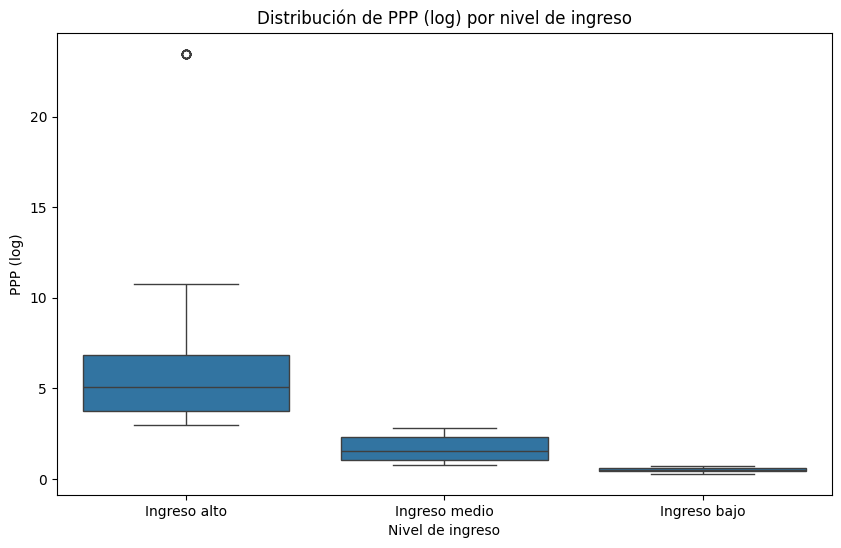

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Creamos una nueva columna la cual tiene la transformación de "ppp" a logarítmo
df_indice_pobreza['ppp_log'] = np.log1p(df_indice_pobreza['ppp'])

#Valores bajos (0 a 5):países con PPP muy bajo
#Valores medios (5 a 10): países con PPP moderado
#Valores altos (10 a +20):países con PPP muy alto o extremos

#Los calculamos de esta manera porque necesitamos dividir en tres ya que vamos a hacer ingreso alto, medio y bajo
cuartil1 = df_indice_pobreza['ppp_log'].quantile(0.33)
cuartil2 = df_indice_pobreza['ppp_log'].quantile(0.66)

#Clasificación según nivel de ingreso
def clasificar_nivel_ingreso(valor_log):
    if valor_log <= cuartil1:
        return 'Ingreso bajo'
    elif valor_log <= cuartil2:
        return 'Ingreso medio'
    else:
        return 'Ingreso alto'

df_indice_pobreza['nivel_ingreso'] = df_indice_pobreza['ppp_log'].apply(clasificar_nivel_ingreso)

#Verificamos la distribución de categorías
print(df_indice_pobreza['nivel_ingreso'].value_counts())

#Creación del boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df_indice_pobreza, x='nivel_ingreso', y='ppp_log')
plt.title('Distribución de PPP (log) por nivel de ingreso')
plt.ylabel('PPP (log)')
plt.xlabel('Nivel de ingreso')
plt.show()


# Interpretaciones
1.El gráfico muestra la distribución de Paridad Poder Adquisitivo (PPA) en escala logarítmica
# Países de ingreso alto
La caja es más grande, lo que significa mayor variabilidad entre países de ingreso alto.
Existencia de valores atípicos indicando que algunos países de ingreso alto tienen un PPP muy superficial al resto
# Países de ingreso medio
La caja es pequeña , lo que indica que hay menos variación interna (los países se parecen más entre sí)
# Países de ingreso bajo
Tiene los valores de PPA más pequeños de todo el gráfico.
La caja es muy pequeña, lo que indica similitud de PPA entre países de ingresos bajos

# Conclusiones generales
El PPA y la variabilidad disminuyen según el nivel de ingreso.
El análisis refleja que los países de ingreso alto tienen economías con mayor capacidad de compra a diferencia de los países de menos ingreso ya que tienen economías más limitadas, reflejando así una desigualdad significativa



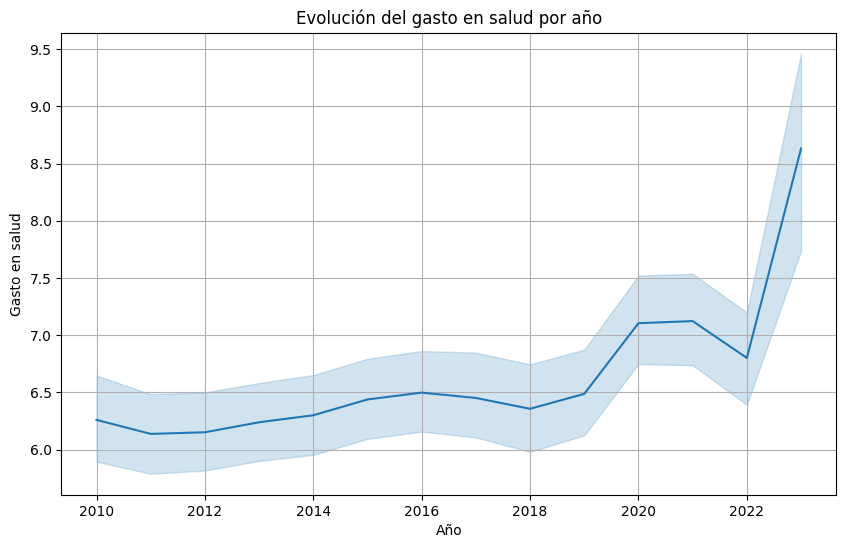

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar años válidos si no lo hiciste antes
df_salud_filtrado = df_unificado[df_unificado['year'].between(2010, 2024)]

# Graficar evolución temporal del gasto en salud
plt.figure(figsize=(10,6))
sns.lineplot(data=df_salud_filtrado, x='year', y='value')
plt.title('Evolución del gasto en salud por año')
plt.ylabel('Gasto en salud')
plt.xlabel('Año')
plt.grid(True)
plt.show()


# Interpretaciones
El gráfico muestra una línea temporal sobre el promedio del gasto en salud desde el 2010 hasta el 2023
Se observa que entre el 2010 y el 2019 hay un crecimiento suave y progresivo en el gasto en salud.
Desde el 2019 se puede notar un incremento en el gasto en salud, esto pudo haber sido debido a la pandemia.
En el 2022 se observa una caída temporal, lo que significa que algunos países redujeron el gasto, probablemente tras la fase crítica de la pandemia.
En el 2023 se observa un crecimiento muy grande en el gasto en salud, esto puede deberse a ajustes económicos


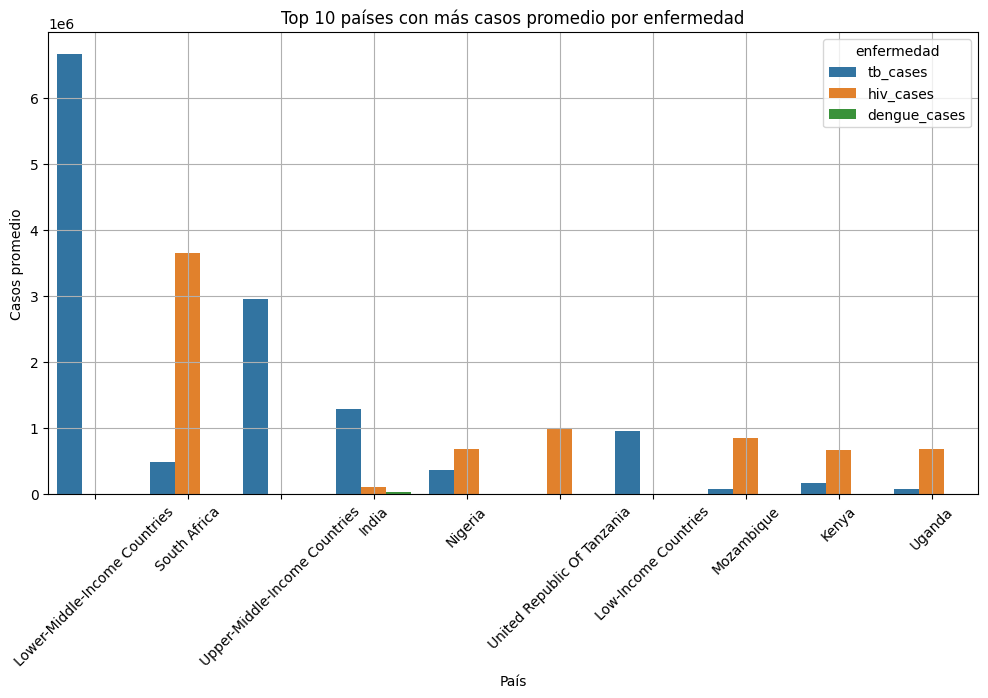

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Limpieza de datos
df_merge['country'] = df_merge['country'].str.strip().str.title()

# Eliminar entradas que no son países reales
excluir = ['Africa', 'Asia', 'Europe', 'Oceania', 'World']
df_merge = df_merge[~df_merge['country'].isin(excluir)]

#Calcular promedios
df_promedio = df_merge.groupby('country')[['tb_cases','hiv_cases','dengue_cases']].mean().reset_index()

#Eliminar países con todos los valores en cero
df_promedio = df_promedio[(df_promedio[['tb_cases','hiv_cases','dengue_cases']] != 0).any(axis=1)]

#Calcular total de casos promedio por país
df_promedio['total'] = df_promedio[['tb_cases','hiv_cases','dengue_cases']].sum(axis=1)

#Seleccionar los 10 países con más casos promedio
top10 = df_promedio.nlargest(10, 'total')

#Reorganizar para graficar
df_promedio_melt = top10.melt(
    id_vars='country',
    value_vars=['tb_cases','hiv_cases','dengue_cases'],
    var_name='enfermedad',
    value_name='casos'
)

#Creación del gráfico
plt.figure(figsize=(12,6))
sns.barplot(data=df_promedio_melt, x='country', y='casos', hue='enfermedad')
plt.title('Top 10 países con más casos promedio por enfermedad')
plt.ylabel('Casos promedio')
plt.xlabel('País')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Interpretaciones
El gráfico muestra un ranking de los 10 países con mayor cantidad promedio de casos en 3 enfermedades: tuberculosis, VIH y dengue
Países que destacan por tuberculosis
Lower-Middle-Income-Countries es el país que tiene la barra azul más alta de todo el gráfico, lo que indica que tiene los mayores casos promedio de tuberculosis (más de 6 millones).
Upper-Middle-Income-Countries tiene el segundo lugar con casi 3 millones.
La tuberculosis es la enfermedad más prevalente en países de ingresos medios, superando por mucho el VIH y dengue
# País donde el VIH es más alto
South Africa presenta uno de los valores más altos del gráfico con más de 3 millones, lo que indica que tiene una de las epidemias de VIH más grandes
# País donde el dengue es más alto
La India es el único país en el gráfico donde el dengue aparece con una cifra visible
# Conclusiones generales
La tuberculosis es la enfermedad que predomina en el gráfico, luego sigue VIH que es la enfermedad predominante en África y por último el dengue, que es el que presenta menos casos


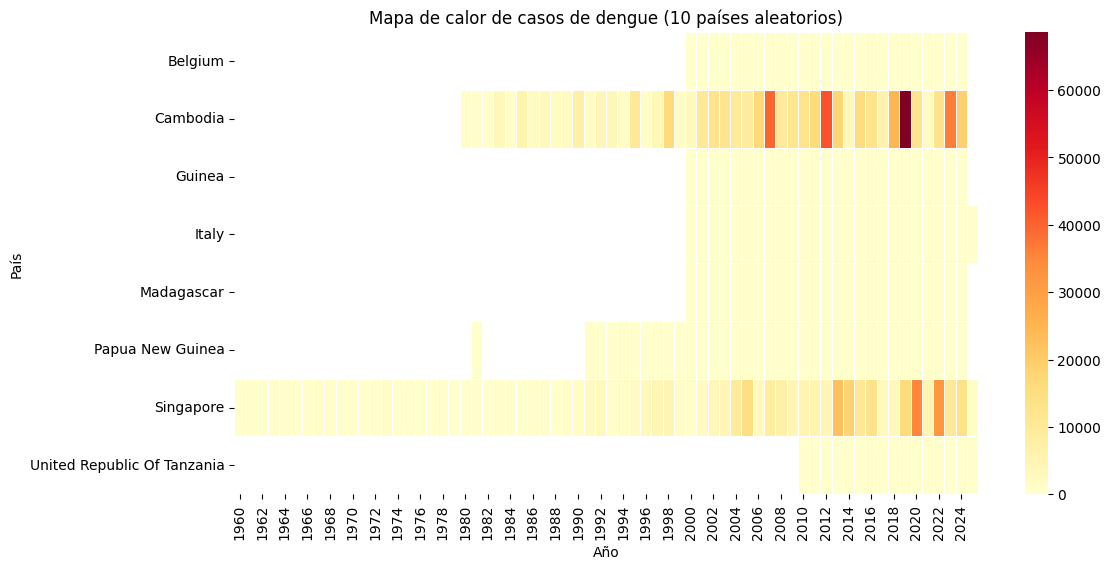

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar datos válidos
df_dengue = df_merge.dropna(subset=['dengue_cases'])

# Seleccionar 10 países aleatorios con datos
paises_dengue = df_dengue['country'].dropna().unique()
paises_seleccionados = pd.Series(paises_dengue).sample(8, random_state=70).tolist()

df_dengue_filtrado = df_dengue[df_dengue['country'].isin(paises_seleccionados)]

# Crear tabla pivote
tabla_dengue = df_dengue_filtrado.pivot_table(
    index='country',
    columns='year',
    values='dengue_cases',
    aggfunc='sum'
)

# Graficar heatmap
plt.figure(figsize=(12,6))
sns.heatmap(tabla_dengue, cmap='YlOrRd', linewidths=0.5)
plt.title('Mapa de calor de casos de dengue (10 países aleatorios)')
plt.xlabel('Año')
plt.ylabel('País')
plt.show()



# Interpretaciones
El mapa de calor evidencia diferencias claras en la distribución temporal del dengue entre países.
Camboya muestra múltiples brotes severos a lo largo del tiempo, destacándose como el país con mayor carga de enfermedad en este subconjunto.
Singapur presenta actividad sostenida y brotes relevantes especialmente desde la década del 2000.
Papua New Guinea reporta casos ocasionales, mientras que países como Bélgica, Italia, Guinea, Madagascar y Tanzania mantienen niveles cercanos a cero en la mayoría de los años.
En conjunto, el gráfico refleja que la incidencia del dengue se concentra principalmente en países tropicales del sudeste asiático, con patrones de brotes recurrentes y marcados contrastes respecto a regiones no endémicas.


**4.5**Mapas

In [62]:
import geopandas as gpd
import pandas as pd
import folium

world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")
world = world.rename(columns={"NAME": "country"})


df_unificado["total_cases"] = (
    df_unificado["dengue_cases"].fillna(0) +
    df_unificado["hiv_cases"].fillna(0) +
    df_unificado["tb_cases"].fillna(0)
)

df_totales = df_unificado.groupby(["country", "year"], as_index=False)["total_cases"].sum()

def mapa_por_anio(anio):

    df_anio = df_totales[df_totales["year"] == anio]

    mapa_gdf = world.merge(df_anio, on="country", how="left")

    m = folium.Map(location=[20, 0], zoom_start=2)

    folium.Choropleth(
        geo_data=mapa_gdf,
        name="choropleth",
        data=mapa_gdf,
        columns=["country", "total_cases"],
        key_on="feature.properties.country",
        fill_color="YlOrRd",
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=f"Total de casos en {anio}"
    ).add_to(m)

    folium.LayerControl().add_to(m)

    return m

mapa_por_anio(2020)


4.6 Estadística descriptiva y simulación


In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#Normalizamos los nombres de los país
df_merge['country'] = df_merge['country'].str.strip().str.title()

#Eliminamos entradas no válidas
excluir = ['Africa', 'Asia', 'Europe', 'Oceania', 'World']
df_merge = df_merge[~df_merge['country'].isin(excluir)]

#Filtramos países con al menos un dato válido
df_filtrado = df_merge[(df_merge[['tb_cases','hiv_cases','dengue_cases']] != 0).any(axis=1)]

#Estadística descriptiva por país
desc = df_filtrado.groupby('country')[['tb_cases','hiv_cases','dengue_cases']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

#Percentiles 25 y 75
percentiles = df_filtrado.groupby('country')[['tb_cases','hiv_cases','dengue_cases']].quantile([0.25, 0.75]).unstack()

#Mostrar resumen para primeros países
print("Medidas descriptivas:")
print(desc.head(5))
print("\nPercentiles:")
print(percentiles.head(5))

Medidas descriptivas:
                tb_cases                                  hiv_cases          \
                    mean   median       std  min      max      mean  median   
country                                                                       
Afghanistan     45666.67  51000.0  25674.80  0.0  75000.0   1092.57     0.0   
Albania           505.60    490.0    131.47  0.0    700.0    424.00     0.0   
Algeria         25160.00  26000.0   5691.22  0.0  30000.0   8344.20  5444.0   
American Samoa      2.10      2.0      2.16  0.0      7.0      0.00     0.0   
Andorra             6.92      6.0      3.90  1.0     14.0      0.00     0.0   

                                      dengue_cases                              
                    std  min      max         mean median     std  min     max  
country                                                                         
Afghanistan     1423.92  0.0   3812.0       284.03    0.0  940.39  0.0  4850.0  
Albania          549.

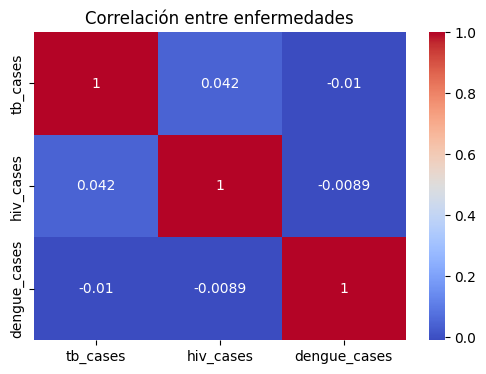

In [64]:
#CORRELACIÓN ENTRE INDICADORES
corr = df_filtrado[['tb_cases','hiv_cases','dengue_cases']].dropna().corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre enfermedades')
plt.show()

# Interpretaciones
El siguiente gráfico muestra una correlación entre enfermedades

# Correlación de Pearson
1 Correlación positiva (cuando una variable aumenta la otra también)
-1 Correlación negativa (cuando una variable aumenta la otra disminuye)
0 sin correlación lineal

# Correlación entre casos de Tuberculosis y VIH
El número de casos de tuberculosis y el número de casos de VIH tienen una relación lineal muy pequeña en los datos analizados. Un aumento en los casos de una no está fuertemente asociado con un aumento en los casos de la otra
# Correlación entre casos de Tuberculosis y Dengue
Indica una correlación negativa extremadamente débil (casi nula), no hay una relación lineal significativa entre los casos de tuberculosis y los casos de dengue
# Correlación entre casos de VIH y Dengue
El valor es extremadamente cercano a cero y negativo. Indica una correlación negativa extremadamente débil (casi nula), no hay una relación lineal significativa entre los casos de VIH y los casos de dengue
# Conclusión general
El análisis de esta matriz de correlación sugiere que, según los datos utilizados para generar el gráfico, no existe una relación lineal significativa entre el número de casos de estas tres enfermedades.


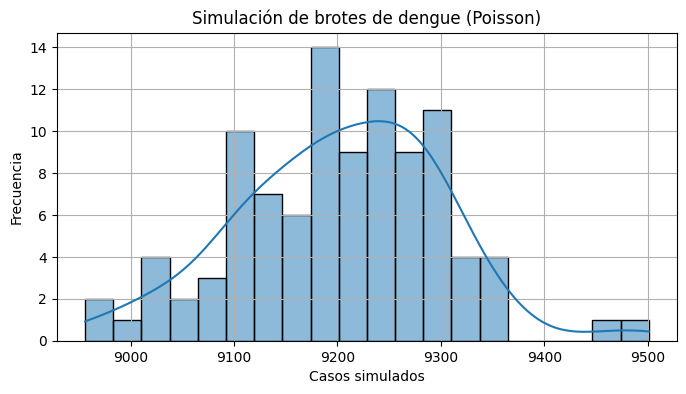

In [91]:
media_dengue = df_filtrado['dengue_cases'].dropna().mean()

# Simulación con distribución Poisson
simulacion_dengue = np.random.poisson(lam=media_dengue, size=100)

plt.figure(figsize=(8,4))
sns.histplot(simulacion_dengue, bins=20, kde=True)
plt.title('Simulación de brotes de dengue (Poisson)')
plt.xlabel('Casos simulados')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

7. Shiny para Python

In [66]:
df_unificado

,country,year,dengue_cases,tb_cases,hiv_cases,value,ppp,total_cases
8,afganistan,2010,NaN,NaN,NaN,8.569672,NaN,0.0
9,afganistan,2011,NaN,NaN,NaN,8.561908,NaN,0.0
10,afganistan,2012,NaN,NaN,NaN,7.897169,NaN,0.0
11,afganistan,2013,NaN,NaN,NaN,8.805964,NaN,0.0
12,afganistan,2014,NaN,NaN,NaN,9.528878,NaN,0.0
...,...,...,...,...,...,...,...,...
16180,Sub-Saharan Africa,2018,NaN,NaN,NaN,4.775709,NaN,0.0
16181,Sub-Saharan Africa,2019,NaN,NaN,NaN,4.765230,NaN,0.0
16182,Sub-Saharan Africa,2020,NaN,NaN,NaN,5.147791,NaN,0.0
16183,Sub-Saharan Africa,2021,NaN,NaN,NaN,5.327709,NaN,0.0


In [71]:
!pip install shiny pyngrok

In [82]:
NGROK_TOKEN = "" #aqui se pega el token sin espacios

In [90]:
!pip install shiny pyngrok

from shiny import App, ui, render, reactive
import pandas as pd
import matplotlib.pyplot as plt
from pyngrok import ngrok
import threading

df = df_unificado.copy()
df = df.sort_values(["country", "year"])

app_ui = ui.page_navbar(
    ui.nav_panel(
        "Dashboard",
        ui.layout_sidebar(
            ui.sidebar(
                ui.h3("Filtros"),
                ui.input_select(
                    "pais",
                    "País:",
                    sorted(df["country"].dropna().unique())
                ),
                ui.input_slider(
                    "year_range",
                    "Rango de años:",
                    min(df["year"]),
                    max(df["year"]),
                    value=(min(df["year"]), max(df["year"]))
                ),
                ui.input_select(
                    "indicador",
                    "Indicador:",
                    {
                        "dengue_cases": "Casos de Dengue",
                        "tb_cases": "Casos de Tuberculosis",
                        "hiv_cases": "Casos de VIH",
                        "value": "PPP (World Bank)",
                        "ppp": "PPP Alternativo"
                    }
                )
            ),
            ui.h3("Tabla de Datos"),
            ui.output_table("tabla"),
            ui.h3("Gráfico del Indicador"),
            ui.output_plot("grafico")
        )
    ),
    ui.nav_panel(
        "Descripción",
        ui.p("""
        Esta aplicación permite visualizar indicadores de salud y PPP
        filtrados por país e intervalo de años usando Shiny para Python.
        """)
    ),
    title="Dashboard Salud & PPP"
)

def server(input, output, session):

    @reactive.Calc
    def datos_filtrados():
        d = df[df["country"] == input.pais()]
        yr_low, yr_high = input.year_range()
        return d[(d["year"] >= yr_low) & (d["year"] <= yr_high)]

    @output
    @render.table
    def tabla():
        return datos_filtrados()[["country", "year", input.indicador()]]

    @output
    @render.plot
    def grafico():
        d = datos_filtrados()
        indicador = input.indicador()
        fig, ax = plt.subplots()
        ax.plot(d["year"], d[indicador], marker="o")
        ax.set_title(f"{indicador} en {input.pais()}")
        ax.set_xlabel("Año")
        ax.set_ylabel(indicador)
        ax.grid(True)
        return fig

app = App(app_ui, server)


from shiny import run_app

def run_shiny():
    run_app(app, host="0.0.0.0", port=8000)

threading.Thread(target=run_shiny).start()

# configuracion del ngrok

ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8000)
print("🚀 Tu app está lista en:")
print(public_url)


INFO:     Started server process [6612]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


🚀 Tu app está lista en:
NgrokTunnel: "https://buildingless-unceasingly-crista.ngrok-free.dev" -> "http://localhost:8000"


# 4.8 Bono: ajuste de modelos

In [104]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import numpy as np

df = df_unificado

X = df[["dengue_cases", "tb_cases", "hiv_cases", "ppp", "total_cases"]]
y = df["value"]


imputer = SimpleImputer(strategy="mean")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Resultados del modelo:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

print("\nCoeficientes del modelo:")
print(coeficientes)

print("\nIntercepto del modelo:", modelo.intercept_)


Resultados del modelo:
R²: 0.0005
RMSE: 1.8537

Coeficientes del modelo:
       Variable   Coeficiente
0  dengue_cases -3.582078e-07
1      tb_cases -2.879671e-07
2     hiv_cases -2.925906e-07
3           ppp -1.979533e-05
4   total_cases  2.845160e-07

Intercepto del modelo: 6.543461000869339


Se intenta realizar un **modelo de regresion lineal**, sin embargo, bajo la advertencia de que varios valores faltantes de los data frames fueron imputados.
Esto significa que la confiabilidad del modelo es realmente baja.

Ademas, segun los resultados del modelo, no se puede concluir nada, por la incosistecia teoria de los resultados.

Conclusion: **El modelo entrenado no esta capatando ninguna relacion significativa.**

Referencia librerias: https://cienciadedatos.net/documentos/py10-regresion-lineal-python